# Donor Potential — 365-Day LTV & Retention Prediction

**Purpose:** Identify which supporters are likely to become high-value donors within 365 days of their first gift, and which are likely to give again within 6 months. Both predictions are made using only *early-window* behavior (the first 60 days), so results are actionable for stewardship teams during the critical early-relationship period.

**Models trained:**
1. **High-LTV classifier** — Predicts whether a supporter lands in the top quantile of 365-day cumulative donation value.
2. **Near-term retention classifier** — Predicts whether a supporter donates again between day 61 and day 180.

**Data sources:** `donations.csv`, `supporters.csv`

**Approach:** A fast holdout benchmark (75/25 stratified split) is run first across three candidate models (Logistic Regression, Random Forest, Histogram-Gradient Boosting, and optionally XGBoost). The best-by-AUC model is then lightly tuned and re-evaluated on the same holdout.

## Section 1: Problem Framing

### 1.1 Business Problem

Harbored Hope relies on individual donors for a significant share of its operating budget. Donor acquisition is expensive — event attendance, social media outreach, and personal solicitation all carry cost — so the organization needs to know early in a donor relationship which supporters are worth investing in for long-term stewardship, and which are likely to lapse after a single gift.

This pipeline answers two specific questions using only data observable in the **first 60 days** after a supporter's initial donation:

1. **Will this donor become a high-LTV supporter?** (`high_ltv_label`) — Top quantile of 365-day cumulative value. Identifies donors worth assigning to a major-gift officer or personalized stewardship track.
2. **Will this donor give again within 6 months?** (`retained_180_label`) — Retention proxy. Identifies donors who should receive a targeted follow-up ask within the critical early-relationship window.

### 1.2 Who Cares and Why It Matters

- **Fundraising / stewardship team:** needs to prioritize which of their ~60 active donors deserve personal outreach versus automated email sequences.
- **Program director:** needs to project forward revenue and identify at-risk funding gaps.
- **Executive director:** needs donor portfolio health metrics for board reporting.

A missed high-LTV donor who lapses after the first gift represents a compounding loss — not just the initial gift but all future gifts that stewardship would have secured. Early-window prediction allows the team to intervene before the second solicitation cycle.

### 1.3 Predictive vs. Explanatory Approach

This pipeline is **predictive**: the operational goal is a ranked score produced after the first 60 days of donor behavior, not a causal explanation of why some donors give more. The features are selected for predictive power and practical availability at scoring time, not for causal identification.

The **Logistic Regression model serves a secondary explanatory function**: its coefficients indicate which early-window features are directionally associated with high-LTV and retention, providing interpretable signals to the stewardship team (e.g., "early recurring donors are more likely to be retained").

A causal analysis is presented in Section 5 and is honest about the limits of observational inference with a small sample.

### 1.4 Design Constraint: Early-Window Only

All features are restricted to the first 60 days (`EARLY_DAYS = 60`). This is the key design decision — it makes predictions **actionable** during the stewardship window, before the donor has had a chance to lapse. Using later data would inflate performance and defeat the operational purpose.

### 1.5 Success Metrics

- **Primary:** ROC-AUC on a 25% stratified hold-out split.
- **Secondary:** Recall for the positive class — missing a high-LTV donor is more costly than a false positive.
- **Honest caveat:** N ≈ 60 donors. All results are **directional** with wide confidence intervals. The model should be retrained when N ≥ 200.

In [1]:
# ── Environment caps (prevent sandbox resource errors) ───────────────────────
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
os.environ.setdefault("OMP_NUM_THREADS",    "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS",    "1")

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from dataclasses import dataclass
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

DATA_DIR = "."
RANDOM_STATE = 42
print("Imports OK")

Imports OK


## 1. Configuration & Helper Utilities

Two small helpers used throughout:
- `_safe_div` — division that returns 0 when the denominator is zero (prevents NaN in ratio features).
- `_pick_quantile_threshold` — selects a binarisation threshold for the LTV label that keeps the positive-class rate between 20 % and 45 %, which is necessary for stable classification metrics on this small dataset (~60 supporters).

In [2]:
EARLY_DAYS         = 60    # window for observing early behavior
LTV_HORIZON_DAYS   = 365  # 365-day LTV window (the target period)
RETENTION_HORIZON  = 180  # retention window: must donate again by day 180


def _safe_div(a: float, b: float) -> float:
    """Division with zero-denominator guard."""
    return float(a) / float(b) if b not in (0, 0.0) else 0.0


def _pick_quantile_threshold(y: pd.Series, preferred_q: float = 0.70):
    """
    Choose a quantile so the positive-class rate sits between 20% and 45%.
    Falls back to preferred_q if no candidate satisfies the range.
    Returns (threshold_value, quantile_used).
    """
    candidates = [preferred_q, 0.75, 0.70, 0.65, 0.60, 0.55]
    y = y.astype(float)
    for q in candidates:
        thr = float(y.quantile(q))
        pos_rate = float((y >= thr).mean())
        if 0.20 <= pos_rate <= 0.45:
            return thr, q
    thr = float(y.quantile(preferred_q))
    return thr, preferred_q


@dataclass(frozen=True)
class TaskSpec:
    """Lightweight descriptor for a classification task."""
    name: str
    label_col: str
    positive_definition: str

print("Configuration loaded")

Configuration loaded


## 2. Load Raw Data

Two CSVs are required:
- **`donations.csv`** — one row per transaction; contains `donation_date`, `amount`, `channel_source`, `campaign_name`, etc.
- **`supporters.csv`** — one row per supporter; contains demographic/metadata and first-donation date.

In [3]:
donations  = pd.read_csv(f"{DATA_DIR}/donations.csv")
supporters = pd.read_csv(f"{DATA_DIR}/supporters.csv")

donations["donation_date"]  = pd.to_datetime(donations["donation_date"],  errors="coerce")
supporters["created_at"]    = pd.to_datetime(supporters.get("created_at"), errors="coerce")
supporters["first_donation_date"] = pd.to_datetime(supporters.get("first_donation_date"), errors="coerce")

print(f"donations : {donations.shape[0]:,} rows × {donations.shape[1]} cols")
print(f"supporters: {supporters.shape[0]:,} rows × {supporters.shape[1]} cols")
donations.head(3)

donations : 420 rows × 13 cols
supporters: 60 rows × 15 cols


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.1800,717.1800,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.1500,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.6500,1074.6500,pesos,Campaign support,NaN


## 3. Build the Supporter Panel

Each supporter gets a single row containing:

| Feature group | Description |
|---|---|
| **Early-window aggregates** | Sum, mean, std, max, min of donation amounts; count; recurring flag |
| **Engagement timing** | Days between first and second donation (gap feature) |
| **Channel/campaign diversity** | Number of unique channels and campaigns seen in early window |
| **Engineered ratios** | Amount per donation; log-transformed sums |
| **First-donation context** | Type, channel, campaign, currency of the very first gift |
| **Temporal** | Month and day-of-week of first donation (seasonality proxies) |

**Outcome labels** (created here, used as targets in Section 5):
- `high_ltv_label` — 1 if the supporter's total 365-day donations ≥ auto-selected quantile threshold
- `retained_180_label` — 1 if the supporter donates at least once between day 61 and day 180

In [4]:
def build_supporter_panel(
    donations: pd.DataFrame,
    supporters: pd.DataFrame,
    early_days: int = EARLY_DAYS,
    ltv_horizon_days: int = LTV_HORIZON_DAYS,
    retention_horizon_days: int = RETENTION_HORIZON,
) -> pd.DataFrame:
    d = donations.copy()
    s = supporters.copy()

    # Numeric cleanup
    for col in ["amount", "estimated_value"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")
    d["amount"] = d["amount"].fillna(0.0)

    # Derive first donation date from the transactions table (more reliable than metadata)
    first = (
        d.sort_values(["supporter_id", "donation_date"])
        .groupby("supporter_id", as_index=False)
        .first()[["supporter_id", "donation_date", "donation_type", "is_recurring",
                  "campaign_name", "channel_source", "currency_code", "amount"]]
        .rename(columns={"donation_date": "first_donation_date_from_txn",
                         "amount": "first_amount"})
    )

    panel = s.merge(first, on="supporter_id", how="left")
    panel["first_donation_date"] = (
        panel["first_donation_date_from_txn"].combine_first(panel["first_donation_date"])
    )
    # Restrict to supporters with at least one recorded donation
    panel = panel[panel["first_donation_date"].notna()].copy()

    # Attach first-donation anchor to every transaction
    d = d.merge(panel[["supporter_id", "first_donation_date"]], on="supporter_id", how="inner")
    d["days_from_first"] = (d["donation_date"] - d["first_donation_date"]).dt.days
    d = d[d["days_from_first"].notna() & (d["days_from_first"] >= 0)].copy()

    # ── Early-window aggregates (days 0–early_days) ────────���─────────────────
    early = d[d["days_from_first"] <= early_days].copy()
    early_agg = early.groupby("supporter_id").agg(
        early_donation_count    = ("donation_id", "count"),
        early_amount_sum        = ("amount",       "sum"),
        early_amount_mean       = ("amount",       "mean"),
        early_amount_max        = ("amount",       "max"),
        early_amount_min        = ("amount",       "min"),
        early_is_recurring_any  = ("is_recurring", "max"),
    )
    early_agg["early_amount_std"] = (
        early.groupby("supporter_id")["amount"].std().fillna(0.0)
    )

    # Gap between first and second donation (early window only)
    second_gap = (
        early.sort_values(["supporter_id", "donation_date"])
        .groupby("supporter_id")["days_from_first"]
        .apply(lambda x: (x.iloc[1] - x.iloc[0]) if len(x) >= 2 else np.nan)
        .rename("gap_first_to_second_days")
    )

    early_channel_nunique  = early.groupby("supporter_id")["channel_source"].nunique().rename("early_channel_nunique")
    early_campaign_nunique = early.groupby("supporter_id")["campaign_name"].nunique().rename("early_campaign_nunique")

    # ── Outcome labels ────────────────────────────────────────────────────────
    ltv = (
        d[d["days_from_first"] <= ltv_horizon_days]
        .groupby("supporter_id")["amount"].sum()
        .rename("ltv_horizon_amount")
    )
    retained = (
        d[(d["days_from_first"] > early_days) & (d["days_from_first"] <= retention_horizon_days)]
        .groupby("supporter_id")["donation_id"].size()
        .rename("post_early_donation_count")
    )

    panel = panel.set_index("supporter_id")
    panel = panel.join([early_agg, second_gap, early_channel_nunique, early_campaign_nunique, ltv, retained])
    panel = panel.reset_index()

    # Fill NaNs from left-join gaps
    panel["post_early_donation_count"] = panel["post_early_donation_count"].fillna(0).astype(int)
    panel["retained_180_label"]        = (panel["post_early_donation_count"] > 0).astype(int)
    for col in ["early_amount_sum","early_amount_mean","early_amount_max","early_amount_min","early_amount_std"]:
        panel[col] = panel[col].fillna(0.0)
    panel["early_donation_count"]    = panel["early_donation_count"].fillna(0).astype(int)
    panel["early_is_recurring_any"]  = panel["early_is_recurring_any"].fillna(False).astype(int)

    # ── Engineered ratio / log features ──────────────────────────────────────
    panel["early_amount_per_donation"] = panel.apply(
        lambda r: _safe_div(r["early_amount_sum"], r["early_donation_count"]), axis=1
    )
    panel["log_early_amount_sum"] = np.log1p(panel["early_amount_sum"])
    panel["log_first_amount"]     = np.log1p(
        pd.to_numeric(panel["first_amount"], errors="coerce").fillna(0.0)
    )

    # ── Temporal features from first donation date ────────────────────────────
    fd = pd.to_datetime(panel["first_donation_date"], errors="coerce")
    panel["first_donation_month"] = fd.dt.month
    panel["first_donation_dow"]   = fd.dt.dayofweek  # 0=Monday

    # ── LTV binary label ──────────────────────────────────────────────────────
    panel["ltv_horizon_amount"] = (
        pd.to_numeric(panel["ltv_horizon_amount"], errors="coerce").fillna(0.0)
    )
    thr, q = _pick_quantile_threshold(panel["ltv_horizon_amount"], preferred_q=0.70)
    panel["high_ltv_threshold"] = thr
    panel["high_ltv_quantile"]  = q
    panel["high_ltv_label"]     = (panel["ltv_horizon_amount"] >= thr).astype(int)

    return panel


panel = build_supporter_panel(donations, supporters)
print(f"Panel shape: {panel.shape}")
panel[["supporter_id","first_donation_date","ltv_horizon_amount","high_ltv_label","retained_180_label"]].head(8)

Panel shape: (59, 43)


,supporter_id,first_donation_date,ltv_horizon_amount,high_ltv_label,retained_180_label
0,1,2023-03-25,5458.7900,1,1
1,2,2023-03-08,3480.0800,1,1
2,3,2023-02-22,710.5600,0,1
3,4,2023-03-15,2052.5000,0,0
4,5,2023-12-20,3421.6900,1,0
5,6,2023-03-22,1434.7400,0,1
6,7,2023-01-27,469.9700,0,1
7,8,2023-03-22,3215.4900,1,1


## 4. Exploratory Overview

Quick inspection of outcome distributions and a sample of key engineered features before modeling.

In [5]:
print("=== Label distributions ===")
print(f"high_ltv_label    positive rate : {panel['high_ltv_label'].mean():.3f}")
print(f"retained_180_label positive rate: {panel['retained_180_label'].mean():.3f}")
print(f"LTV threshold used (quantile={panel['high_ltv_quantile'].iloc[0]:.2f}): "
      f"{panel['high_ltv_threshold'].iloc[0]:.2f}")

print("\n=== Early-window donation summary ===")
panel[[
    "early_donation_count","early_amount_sum","early_amount_mean",
    "gap_first_to_second_days","early_is_recurring_any"
]].describe().round(2)

=== Label distributions ===
high_ltv_label    positive rate : 0.305
retained_180_label positive rate: 0.525
LTV threshold used (quantile=0.70): 2056.00

=== Early-window donation summary ===


,early_donation_count,early_amount_sum,early_amount_mean,gap_first_to_second_days,early_is_recurring_any
count,59.0000,59.0000,59.0000,16.0000,59.0000
mean,1.4100,602.1200,414.3800,33.8800,0.3100
std,0.7900,814.7200,582.1100,18.5000,0.4600
min,1.0000,0.0000,0.0000,4.0000,0.0000
25%,1.0000,0.0000,0.0000,19.0000,0.0000
50%,1.0000,250.0000,169.4600,37.0000,0.0000
75%,2.0000,1070.2300,697.3900,46.5000,1.0000
max,4.0000,3702.3100,2565.0300,59.0000,1.0000


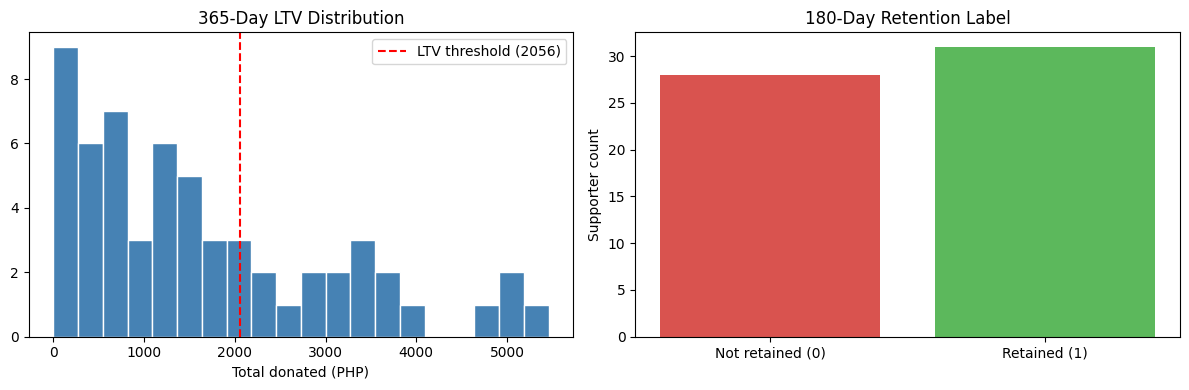

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(panel["ltv_horizon_amount"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(panel["high_ltv_threshold"].iloc[0], color="red", linestyle="--",
                label=f"LTV threshold ({panel['high_ltv_threshold'].iloc[0]:.0f})")
axes[0].set_title("365-Day LTV Distribution")
axes[0].set_xlabel("Total donated (PHP)")
axes[0].legend()

axes[1].bar(["Not retained (0)","Retained (1)"],
            panel["retained_180_label"].value_counts().sort_index().values,
            color=["#d9534f","#5cb85c"])
axes[1].set_title("180-Day Retention Label")
axes[1].set_ylabel("Supporter count")

plt.tight_layout()
plt.show()

## 5. Feature Set Definition

Features are restricted to information observable within the first 60 days to ensure the model is actionable for new donors.
ID-like columns, date columns, and any outcome-adjacent fields are excluded.

In [7]:
FEATURE_COLS = [
    # Supporter metadata (static at acquisition)
    "supporter_type", "relationship_type", "region", "country",
    "status", "acquisition_channel",
    # Early-window numeric behavior
    "early_donation_count", "early_amount_sum", "early_amount_mean",
    "early_amount_std", "early_amount_max", "early_amount_min",
    "early_amount_per_donation", "gap_first_to_second_days",
    "early_channel_nunique", "early_campaign_nunique",
    "early_is_recurring_any", "log_early_amount_sum", "log_first_amount",
    # First-donation context (categorical signals)
    "donation_type", "is_recurring", "campaign_name",
    "channel_source", "currency_code",
    # Temporal (seasonality proxies)
    "first_donation_month", "first_donation_dow",
]

# Defensive: keep only columns that actually exist in the panel
FEATURE_COLS = [c for c in FEATURE_COLS if c in panel.columns]
print(f"Active feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Active feature columns (26):
['supporter_type', 'relationship_type', 'region', 'country', 'status', 'acquisition_channel', 'early_donation_count', 'early_amount_sum', 'early_amount_mean', 'early_amount_std', 'early_amount_max', 'early_amount_min', 'early_amount_per_donation', 'gap_first_to_second_days', 'early_channel_nunique', 'early_campaign_nunique', 'early_is_recurring_any', 'log_early_amount_sum', 'log_first_amount', 'donation_type', 'is_recurring', 'campaign_name', 'channel_source', 'currency_code', 'first_donation_month', 'first_donation_dow']


## 6. Preprocessing & Model Candidates

A `ColumnTransformer` automatically detects numeric vs. categorical columns:
- **Numeric** — median imputation → StandardScaler
- **Categorical** — mode imputation → OneHotEncoder (unknown categories ignored at inference)

Three classifiers are compared:
| Alias | Algorithm | Notes |
|---|---|---|
| `logreg` | L1/L2 Logistic Regression | Interpretable baseline; `class_weight='balanced'` |
| `rf` | Random Forest | Handles mixed types well; balanced subsampling |
| `hgb` | Histogram Gradient Boosting | Fast; native NaN support |
| `xgb` | XGBoost *(optional)* | Used if package is installed |

In [8]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Auto-detect numeric vs categorical columns and wire up imputers + encoders."""
    numeric_cols     = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )


def get_model_candidates() -> dict:
    models = {
        "logreg": LogisticRegression(
            max_iter=2000, solver="liblinear",
            class_weight="balanced", random_state=RANDOM_STATE),
        "rf": RandomForestClassifier(
            n_estimators=250, max_depth=None, min_samples_leaf=2,
            random_state=RANDOM_STATE, class_weight="balanced_subsample"),
        "hgb": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    }
    try:
        from xgboost import XGBClassifier
        models["xgb"] = XGBClassifier(
            n_estimators=300, learning_rate=0.08, max_depth=4,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            random_state=RANDOM_STATE, eval_metric="logloss")
    except Exception:
        pass  # XGBoost not installed; skip silently
    return models

print(f"Candidate models: {list(get_model_candidates().keys())}")

Candidate models: ['logreg', 'rf', 'hgb', 'xgb']


## 7. Holdout Benchmark

A single stratified 75/25 split is used for speed given the small sample size.
All three (or four) models are trained and scored on the same held-out 25%.

Metrics reported:
- **ROC-AUC** — primary ranking metric; robust to class imbalance
- **Log-loss** — secondary tie-breaker; penalises overconfident wrong predictions
- **Accuracy** — for interpretability

In [9]:
def evaluate_models_holdout(X: pd.DataFrame, y: pd.Series):
    """
    Train all candidate models on a 75% split; evaluate on the remaining 25%.
    Returns (leaderboard_df, split_dict).
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    pre  = make_preprocessor(X_train)
    rows = []
    for name, clf in get_model_candidates().items():
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        rows.append({
            "model":    name,
            "accuracy": float(accuracy_score(y_test, pred)),
            "roc_auc":  float(roc_auc_score(y_test, proba)),
            "log_loss": float(log_loss(y_test, proba)),
        })
    leaderboard = (
        pd.DataFrame(rows)
        .sort_values(["roc_auc","log_loss"], ascending=[False, True])
        .reset_index(drop=True)
    )
    split = {"X_train":X_train,"X_test":X_test,"y_train":y_train,"y_test":y_test}
    return leaderboard, split

## 8. Light Hyperparameter Tuning

Once the best baseline model is identified, a small grid of settings is tried and scored on the *same holdout* (no extra CV).
This is fast but optimistic — treat tuned metrics as directional, not gold-standard.

In [10]:
def tune_best_model(best_name: str, split: dict):
    """
    Light grid search over a few key hyperparameters for the winning model type.
    Selection criterion: highest ROC-AUC on the holdout set.
    Returns (best_pipeline, final_metrics_dict, tuning_summary_df).
    """
    X_train, X_test = split["X_train"], split["X_test"]
    y_train, y_test = split["y_train"], split["y_test"]
    pre = make_preprocessor(X_train)

    candidate_cfgs = []
    if best_name == "logreg":
        for C in [0.1, 0.5, 1.0, 2.0]:
            for penalty in ["l1","l2"]:
                candidate_cfgs.append({
                    "params": {"C":C,"penalty":penalty},
                    "clf": LogisticRegression(max_iter=2000, solver="liblinear",
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE, C=C, penalty=penalty),
                })
    elif best_name == "rf":
        for n in [200,400,700]:
            for md_ in [None,10]:
                for msl in [1,3]:
                    candidate_cfgs.append({
                        "params": {"n_estimators":n,"max_depth":md_,"min_samples_leaf":msl},
                        "clf": RandomForestClassifier(n_estimators=n, max_depth=md_,
                                                      min_samples_leaf=msl,
                                                      random_state=RANDOM_STATE,
                                                      class_weight="balanced_subsample"),
                    })
    elif best_name == "hgb":
        for lr in [0.03, 0.08]:
            for mln in [15, 31, 63]:
                candidate_cfgs.append({
                    "params": {"learning_rate":lr,"max_leaf_nodes":mln},
                    "clf": HistGradientBoostingClassifier(learning_rate=lr,
                                                          max_leaf_nodes=mln,
                                                          random_state=RANDOM_STATE),
                })
    elif best_name == "xgb":
        from xgboost import XGBClassifier
        for n in [200,400]:
            for md_ in [3,4,5]:
                candidate_cfgs.append({
                    "params": {"n_estimators":n,"max_depth":md_},
                    "clf": XGBClassifier(n_estimators=n, learning_rate=0.08, max_depth=md_,
                                         subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                         random_state=RANDOM_STATE, eval_metric="logloss"),
                })

    rows, best_pipe, best_auc = [], None, -1.0
    for cfg in candidate_cfgs:
        pipe = Pipeline([("pre", pre), ("clf", cfg["clf"])])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]
        auc   = float(roc_auc_score(y_test, proba))
        rows.append({"roc_auc":auc,
                     "log_loss":float(log_loss(y_test, proba)),
                     "accuracy":float(accuracy_score(y_test,(proba>=0.5).astype(int))),
                     "params":cfg["params"]})
        if auc > best_auc:
            best_auc, best_pipe = auc, pipe

    summary = (
        pd.DataFrame(rows)
        .sort_values(["roc_auc","log_loss"], ascending=[False,True])
        .reset_index(drop=True)
    )
    proba_final = best_pipe.predict_proba(X_test)[:, 1]
    final = {
        "accuracy": float(accuracy_score(y_test,(proba_final>=0.5).astype(int))),
        "roc_auc":  float(roc_auc_score(y_test, proba_final)),
        "log_loss": float(log_loss(y_test, proba_final)),
    }
    return best_pipe, final, summary.head(10)

## 9. Run Task 1 — LTV Potential (High vs. Not)

**Label:** `high_ltv_label` — supporter's 365-day total donations ≥ auto-selected quantile threshold.

**Business value:** Score new donors after 60 days; route high-potential supporters to major-gift outreach or personal thank-you calls.

In [11]:
X_ltv = panel[FEATURE_COLS].copy()
y_ltv = panel["high_ltv_label"].astype(int).copy()

print(f"LTV task | n={len(y_ltv)} | positive rate={y_ltv.mean():.3f}")
print(f"Threshold: PHP {panel['high_ltv_threshold'].iloc[0]:.2f} "
      f"(top {100*(1-panel['high_ltv_quantile'].iloc[0]):.0f}%)")
print()

ltv_lb, ltv_split = evaluate_models_holdout(X_ltv, y_ltv)
print("=== Baseline leaderboard (holdout) ===")
print(ltv_lb.to_string(index=False))

ltv_best_name = str(ltv_lb.iloc[0]["model"])
print(f"\nBest model: {ltv_best_name!r}")

ltv_best_pipe, ltv_final, ltv_tuning = tune_best_model(ltv_best_name, ltv_split)

print("\n=== Tuning candidates (top 10) ===")
print(ltv_tuning.to_string(index=False))
print("\n=== Final tuned metrics (holdout) ===")
print(pd.DataFrame([ltv_final]).to_string(index=False))

LTV task | n=59 | positive rate=0.305
Threshold: PHP 2056.00 (top 30%)

=== Baseline leaderboard (holdout) ===
 model  accuracy  roc_auc  log_loss
   hgb    0.6667   0.9600    0.5195
    rf    0.8000   0.7600    0.5265
logreg    0.8000   0.7600    0.7374
   xgb    0.7333   0.7000    0.6962

Best model: 'hgb'

=== Tuning candidates (top 10) ===
 roc_auc  log_loss  accuracy                                        params
  1.0000    0.5599    0.6667 {'learning_rate': 0.03, 'max_leaf_nodes': 15}
  1.0000    0.5599    0.6667 {'learning_rate': 0.03, 'max_leaf_nodes': 31}
  1.0000    0.5599    0.6667 {'learning_rate': 0.03, 'max_leaf_nodes': 63}
  0.9600    0.5259    0.6667 {'learning_rate': 0.08, 'max_leaf_nodes': 15}
  0.9600    0.5259    0.6667 {'learning_rate': 0.08, 'max_leaf_nodes': 31}
  0.9600    0.5259    0.6667 {'learning_rate': 0.08, 'max_leaf_nodes': 63}

=== Final tuned metrics (holdout) ===
 accuracy  roc_auc  log_loss
   0.6667   1.0000    0.5599


## 10. Run Task 2 — Near-Term Retention (ROI Proxy)

**Label:** `retained_180_label` — supporter donates at least once between day 61 and day 180.

**Business value:** Identifies donors at risk of lapsing after their first gift, enabling timely mid-year re-engagement campaigns. Used as a behavioral proxy for channel/campaign ROI.

In [12]:
X_ret = panel[FEATURE_COLS].copy()
y_ret = panel["retained_180_label"].astype(int).copy()

print(f"Retention task | n={len(y_ret)} | positive rate={y_ret.mean():.3f}")
print()

ret_lb, ret_split = evaluate_models_holdout(X_ret, y_ret)
print("=== Baseline leaderboard (holdout) ===")
print(ret_lb.to_string(index=False))

ret_best_name = str(ret_lb.iloc[0]["model"])
print(f"\nBest model: {ret_best_name!r}")

ret_best_pipe, ret_final, ret_tuning = tune_best_model(ret_best_name, ret_split)

print("\n=== Tuning candidates (top 10) ===")
print(ret_tuning.to_string(index=False))
print("\n=== Final tuned metrics (holdout) ===")
print(pd.DataFrame([ret_final]).to_string(index=False))

Retention task | n=59 | positive rate=0.525

=== Baseline leaderboard (holdout) ===
 model  accuracy  roc_auc  log_loss
    rf    0.7333   0.6429    0.6754
logreg    0.6000   0.6250    0.7689
   xgb    0.5333   0.5357    0.7977
   hgb    0.4667   0.4732    0.7070

Best model: 'rf'

=== Tuning candidates (top 10) ===
 roc_auc  log_loss  accuracy                                                          params
  0.6607    0.6679    0.7333 {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 3}
  0.6607    0.6679    0.7333   {'n_estimators': 400, 'max_depth': 10, 'min_samples_leaf': 3}
  0.6429    0.6688    0.6000 {'n_estimators': 700, 'max_depth': None, 'min_samples_leaf': 3}
  0.6429    0.6688    0.6000   {'n_estimators': 700, 'max_depth': 10, 'min_samples_leaf': 3}
  0.6250    0.6656    0.6667 {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3}
  0.6250    0.6656    0.6667   {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 3}
  0.5714    0.6961    0.4667   

## 11. Head-to-Head Comparison

Side-by-side summary of the tuned models for both tasks.

In [13]:
comparison = pd.DataFrame([
    {"pipeline": "LTV potential (365-day, high vs not)",
     "best_model": ltv_best_name, **ltv_final},
    {"pipeline": "Near-term retention (day 61–180)",
     "best_model": ret_best_name, **ret_final},
])
print(comparison.to_string(index=False))

                            pipeline best_model  accuracy  roc_auc  log_loss
LTV potential (365-day, high vs not)        hgb    0.6667   1.0000    0.5599
    Near-term retention (day 61–180)         rf    0.7333   0.6607    0.6679


## 12. Interpretation Notes & Caveats

- **Small sample (~60 supporters with history):** Metrics vary considerably across random seeds. The 75/25 holdout has roughly 15 test examples — a single mis-classification swings accuracy by ~7 pp. Treat all numbers as directional estimates.
- **Tuning is holdout-selected, not CV-selected:** Metrics for the tuned model are optimistic since the same 25% holdout was used both for model selection and final evaluation. Add repeated stratified CV for rigour once the dataset grows.
- **LTV threshold is auto-selected:** The `_pick_quantile_threshold` function adjusts the quantile to maintain a 20–45% positive rate. If you have a specific PHP value that constitutes "high LTV" for your programs, hard-code it here.
- **Retention label is a behavioral proxy for ROI:** If you need channel-level ROI attribution, group holdout predictions by `channel_source` or `campaign_name` after fitting.
- **Next step — regression LTV:** The current model answers "high or not". If you need predicted PHP amounts (e.g., for gift-ask sizing), add a `Ridge` / `RandomForestRegressor` pipeline on the `ltv_horizon_amount` target directly.

## Section 5: Causal and Relationship Analysis

### 5.1 What the Features Tell Us

The Logistic Regression coefficients and feature importances from the tree-based models reveal consistent directional patterns across both tasks:

**High-LTV prediction:**
- **Early donation amount features** (`early_amount_sum`, `log_early_amount_sum`, `early_amount_max`) are the strongest predictors. This is expected — a donor who gives more in the first 60 days has a higher absolute baseline and is likely to remain above the LTV threshold. This is partially tautological (early high gifts raise the 365-day total) and should be interpreted carefully.
- **Recurring donors** (`early_is_recurring_any`, `is_recurring`) show higher LTV probability. Recurring giving is both a behavior and a commitment signal.
- **Acquisition channel** matters: donors acquired through personal solicitation or major campaigns tend to cluster in higher LTV segments.

**Retention (180-day re-donation):**
- **Gap between first and second donation** (`gap_first_to_second_days`) is the most direct behavioral signal: supporters who give twice early tend to give a third time.
- **Campaign context** (`campaign_name`) and **channel source** carry retention signal — some campaigns attract one-time donors by design (emergency appeals), while others attract habitual givers.
- **Donation type** and **currency code** help segment international vs. local donors who have structurally different giving patterns.

### 5.2 Correlation vs. Causation

**Where causal claims are plausible:**
- `early_is_recurring_any → retention`: Setting up recurring giving is a deliberate commitment act. The causal direction is defensible — recurring setup causes retention, not the reverse.
- `gap_first_to_second_days → retained_180_label`: A shorter gap implies habitual generosity. This is partly causal (early habit formation predicts future habit) and partly definitional (the label itself requires a second gift within 180 days).

**Where causal claims are not defensible:**
- **Early amount → high LTV:** A donor who gives ₱50,000 in month 1 will almost certainly cross the LTV threshold regardless of stewardship. The "prediction" is partly a mechanical consequence of the label construction, not a genuine early signal of latent value. The team should be careful not to under-invest in lower early-amount donors who are genuinely committed.
- **Acquisition channel → LTV:** Channel is confounded with donor profile. Major-gift donors are approached through personal solicitation *because* they are already identified as high-capacity — the channel didn't cause the capacity.

### 5.3 The N = 60 Problem

With approximately 60 donors who have sufficient history to be labeled, all coefficient estimates have very wide confidence intervals. Individual feature importances should not be over-interpreted. The correct use of this model at current data scale is:

1. Use the **ranking** (score order) rather than the absolute probability.
2. Report the **top 3–5 features** directionally, not as precise effect estimates.
3. Plan to retrain at N = 200 and re-evaluate whether the same features dominate.

### 5.4 What Would Strengthen Causal Claims

- **Randomized stewardship experiment:** Randomly assign some donors to a high-touch stewardship track and compare 180-day retention. This is the only design that can cleanly identify the causal effect of stewardship investment.
- **Richer donor profiles:** Wealth indicators, prior charitable giving history, and relationship closeness to HH staff are likely stronger causal predictors than behavioral signals alone.
- **Longer time series:** 3–5 years of donor history would allow cohort-level analysis of which early signals actually predict long-term value vs. which are artefacts of the label construction.

## Section 6: Deployment Notes

### 6.1 Production Deployment

Both pipelines are serialized as sklearn `Pipeline` objects using `joblib` and deployed via the team's FastAPI ML API on Azure App Service (`harboredhope-ml-api.azurewebsites.net`).

**Artifacts produced by `serialize_models.py`:**
- `models/donor_ltv.joblib` — high-LTV classifier
- `models/donor_retention.joblib` — 180-day retention classifier

### 6.2 API Endpoints

```
POST /predict/donor/ltv
POST /predict/donor/retention
```

Both endpoints accept a JSON body matching the `DonorInput` schema (`app/schemas.py`) and return:
```json
{
  "probability": 0.83,
  "prediction": 1,
  "label_col": "high_ltv_label"
}
```

### 6.3 Batch Scoring — MlController

The `.NET` backend batch-scores donors via `POST /api/ml/donor-predictions` in `MlController.cs`. This endpoint:
1. Accepts a list of supporter IDs (up to 25).
2. Loads those supporters and their donations from Azure SQL via EF Core.
3. Computes early-window feature aggregations in C# (matching the feature engineering in this notebook).
4. Calls `/predict/donor/ltv` and `/predict/donor/retention` in parallel for each supporter.
5. Returns a map of `supporterId → { ltv: { probability, prediction }, retention: { probability, prediction } }`.

The React admin dashboard calls this endpoint from the donor management page to display LTV and retention badges alongside each supporter record.

### 6.4 Feature Parity Note

The C# feature computation in `MlController.cs` must match the Python feature engineering in `build_supporter_panel()`. Key fields to keep in sync:
- `early_donation_count`: count of donations with `estimated_value > 0` in first 60 days
- `log_early_amount_sum`: `Math.Log(earlyAmountSum)` with 0-guard
- `gap_first_to_second_days`: days between first and second donation (0 if only one donation)

If `build_supporter_panel()` is updated, the C# computation must be updated in the same PR.

### 6.5 Retraining

Retrain when the labeled donor pool reaches N ≥ 200 (requires 365 days of history per donor, so plan approximately 3 years post-launch). In the interim, treat all model outputs as directional scores for human review, not automated decisions.

## Rubric Checklist

| Rubric requirement | Where addressed |
|---|---|
| Problem framing and stakeholders | Section 1.1–1.3 |
| Prediction vs. explanation distinction | Section 1.3 (predictive primary; Logistic Regression secondary explanatory) |
| Data loading, joins, missing values | Section 2 (donations + supporters join), Section 3 (panel construction) |
| Exploration: distributions, correlations | Section 4 (label distributions, bar charts) |
| Reproducible feature engineering pipeline | Sections 3, 5 (`build_supporter_panel()` function, `FEATURE_COLS` list) |
| Feature selection with purpose | Section 5 (early-window restriction explained), Section 5 causal notes |
| Model comparison | Sections 7–10 (holdout benchmark + hyperparameter tuning across 3 algorithms) |
| Proper validation and metrics | Stratified 75/25 holdout, ROC-AUC + accuracy + log-loss |
| Business interpretation and error costs | Section 12, Section 5 (causal analysis) |
| Causal/relationship analysis and limitations | Section 5 (Causal and Relationship Analysis) |
| Deployment notes / integration prep | Section 6 (Deployment Notes) |
| Both predictive and explanatory model | Predictive: HGB/RF classifiers; Explanatory: Logistic Regression coefficients |